In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

2026-06-08 11:15:53.518294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780917353.716737      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780917353.772526      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780917354.275228      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780917354.275284      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780917354.275287      58 computation_placer.cc:177] computation placer alr

In [2]:
X, y = make_moons(100, noise = 0.25, random_state = 2)

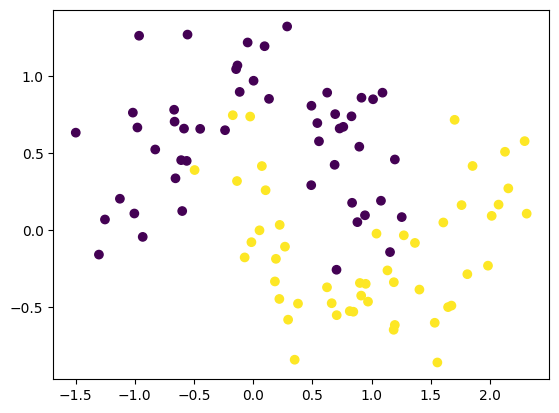

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c = y)
plt.show()

In [4]:
model1  = Sequential()

model1.add(Dense(128, input_dim = 2, activation = "relu"))
model1.add(Dense(128, activation = "relu"))
model1.add(Dense(1, activation = "sigmoid"))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-08 11:16:09.351670: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
adam = Adam(learning_rate = 0.01)
model1.compile(loss = 'binary_crossentropy', optimizer = adam, metrics = ['accuracy'])

history1 = model1.fit(X, y, epochs = 2000, validation_split = 0.2, verbose = 0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 985us/step


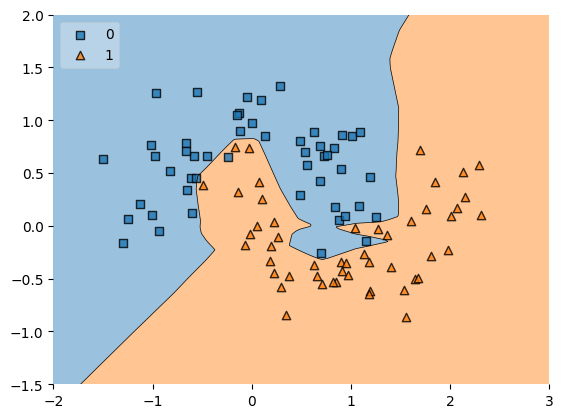

In [6]:
plot_decision_regions(X, y.astype('int'), clf = model1, legend = 2)
plt.xlim(-2, 3)
plt.ylim(-1.5,2)
plt.show()

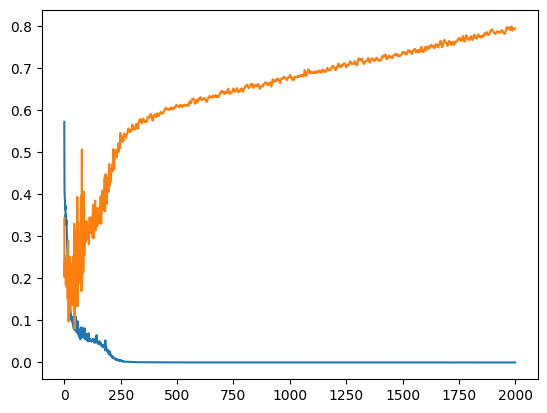

In [7]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [8]:
model2  = Sequential()

model2.add(Dense(128, input_dim = 2, activation = "relu", kernel_regularizer = tensorflow.keras.regularizers.l2(0.05)))
model2.add(Dense(128, activation = "relu", kernel_regularizer = tensorflow.keras.regularizers.l2(0.03)))
model2.add(Dense(1, activation = "sigmoid"))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
adam = Adam(learning_rate = 0.01)
model2.compile(loss = 'binary_crossentropy', optimizer = adam, metrics = ['accuracy'])

history2 = model2.fit(X, y, epochs = 2000, validation_split = 0.2, verbose = 0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


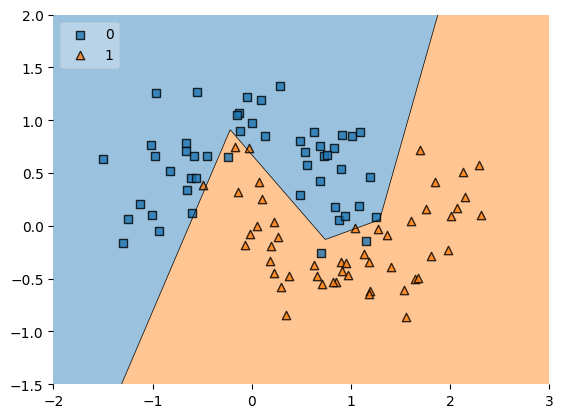

In [10]:
plot_decision_regions(X, y.astype('int'), clf = model2, legend = 2)
plt.xlim(-2, 3)
plt.ylim(-1.5,2)
plt.show()

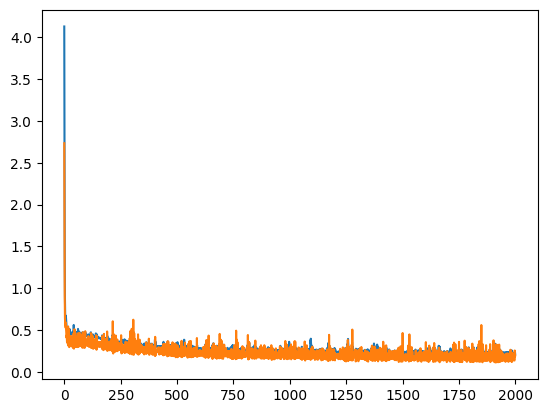

In [11]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [12]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

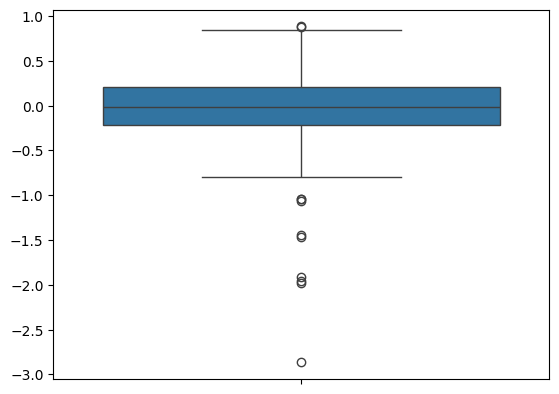

In [13]:
sns.boxplot(model1_weight_layer1)

<Axes: >

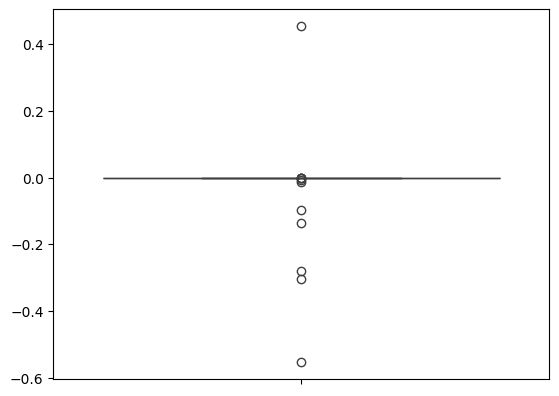

In [14]:
sns.boxplot(model2_weight_layer1)

In [15]:
model1_weight_layer1.max()

np.float32(0.8860376)

In [16]:
model2_weight_layer1.max()

np.float32(0.45390537)

/tmp/ipykernel_58/2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
/tmp/ipykernel_58/2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

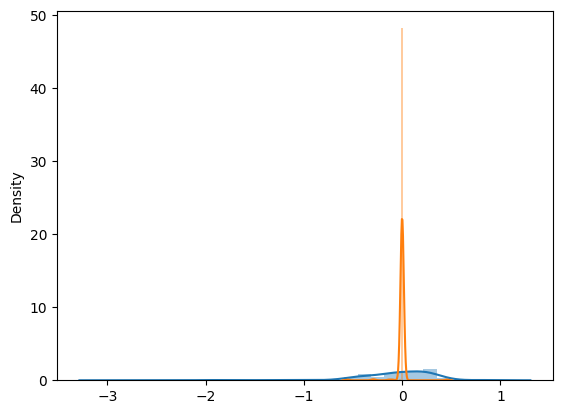

In [17]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [18]:
model1.get_weights()

[array([[ 7.63643086e-02, -2.12340251e-01, -5.76624990e-01,
         -4.88189101e-01,  2.49497503e-01, -2.13416606e-01,
         -1.85535759e-01, -3.60438585e-01, -2.03781370e-02,
         -4.48438048e-01,  2.82455117e-01, -4.42041039e-01,
         -4.35342222e-01,  3.09930801e-01,  3.73468310e-01,
          4.87584285e-02,  3.30746353e-01, -4.03360218e-01,
          1.25089794e-01,  2.84017384e-01, -5.11772633e-01,
         -2.31325790e-01, -6.98079020e-02, -3.35225821e-01,
         -5.07243812e-01, -5.01893401e-01,  1.47259533e-01,
          2.04753295e-01,  4.67254609e-01,  1.79521248e-01,
         -1.58058852e-02,  2.17358083e-01,  2.82694429e-01,
          1.76849708e-01, -4.81223732e-01, -3.93679649e-01,
         -4.36141551e-01, -2.37990189e-02, -1.62870228e-01,
          1.10363383e-02,  2.11693242e-01, -3.83450210e-01,
         -2.77439475e-01, -3.65592614e-02,  7.87160993e-02,
         -4.88014966e-01, -5.03616452e-01,  2.42823631e-01,
         -1.57260120e-01,  2.40087047e-0

In [19]:
model1.get_weights()[0]

array([[ 7.63643086e-02, -2.12340251e-01, -5.76624990e-01,
        -4.88189101e-01,  2.49497503e-01, -2.13416606e-01,
        -1.85535759e-01, -3.60438585e-01, -2.03781370e-02,
        -4.48438048e-01,  2.82455117e-01, -4.42041039e-01,
        -4.35342222e-01,  3.09930801e-01,  3.73468310e-01,
         4.87584285e-02,  3.30746353e-01, -4.03360218e-01,
         1.25089794e-01,  2.84017384e-01, -5.11772633e-01,
        -2.31325790e-01, -6.98079020e-02, -3.35225821e-01,
        -5.07243812e-01, -5.01893401e-01,  1.47259533e-01,
         2.04753295e-01,  4.67254609e-01,  1.79521248e-01,
        -1.58058852e-02,  2.17358083e-01,  2.82694429e-01,
         1.76849708e-01, -4.81223732e-01, -3.93679649e-01,
        -4.36141551e-01, -2.37990189e-02, -1.62870228e-01,
         1.10363383e-02,  2.11693242e-01, -3.83450210e-01,
        -2.77439475e-01, -3.65592614e-02,  7.87160993e-02,
        -4.88014966e-01, -5.03616452e-01,  2.42823631e-01,
        -1.57260120e-01,  2.40087047e-01, -3.65144581e-0

In [20]:
model1.get_weights()[0].shape

(2, 128)

In [21]:
model1.get_weights()[0].reshape(256)

array([ 7.63643086e-02, -2.12340251e-01, -5.76624990e-01, -4.88189101e-01,
        2.49497503e-01, -2.13416606e-01, -1.85535759e-01, -3.60438585e-01,
       -2.03781370e-02, -4.48438048e-01,  2.82455117e-01, -4.42041039e-01,
       -4.35342222e-01,  3.09930801e-01,  3.73468310e-01,  4.87584285e-02,
        3.30746353e-01, -4.03360218e-01,  1.25089794e-01,  2.84017384e-01,
       -5.11772633e-01, -2.31325790e-01, -6.98079020e-02, -3.35225821e-01,
       -5.07243812e-01, -5.01893401e-01,  1.47259533e-01,  2.04753295e-01,
        4.67254609e-01,  1.79521248e-01, -1.58058852e-02,  2.17358083e-01,
        2.82694429e-01,  1.76849708e-01, -4.81223732e-01, -3.93679649e-01,
       -4.36141551e-01, -2.37990189e-02, -1.62870228e-01,  1.10363383e-02,
        2.11693242e-01, -3.83450210e-01, -2.77439475e-01, -3.65592614e-02,
        7.87160993e-02, -4.88014966e-01, -5.03616452e-01,  2.42823631e-01,
       -1.57260120e-01,  2.40087047e-01, -3.65144581e-01, -4.76634771e-01,
        3.98236439e-02,  

In [22]:
model2  = Sequential()

model2.add(Dense(128, input_dim = 2, activation = "relu", kernel_regularizer = tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation = "relu", kernel_regularizer = tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1, activation = "sigmoid"))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
adam = Adam(learning_rate = 0.01)
model2.compile(loss = 'binary_crossentropy', optimizer = adam, metrics = ['accuracy'])

history2 = model2.fit(X, y, epochs = 2000, validation_split = 0.2, verbose = 0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


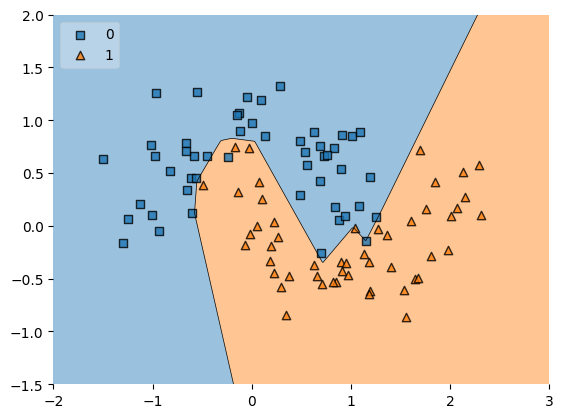

In [24]:
plot_decision_regions(X, y.astype('int'), clf = model2, legend = 2)
plt.xlim(-2, 3)
plt.ylim(-1.5,2)
plt.show()

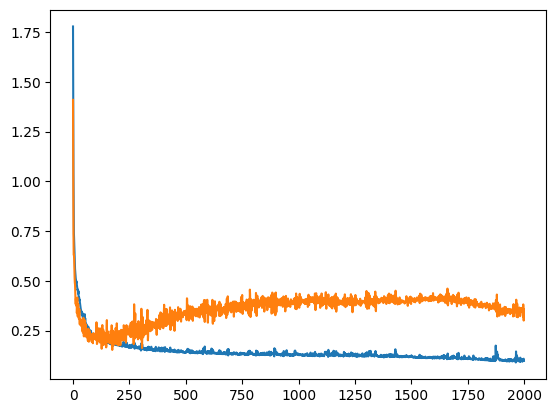

In [25]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [26]:
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

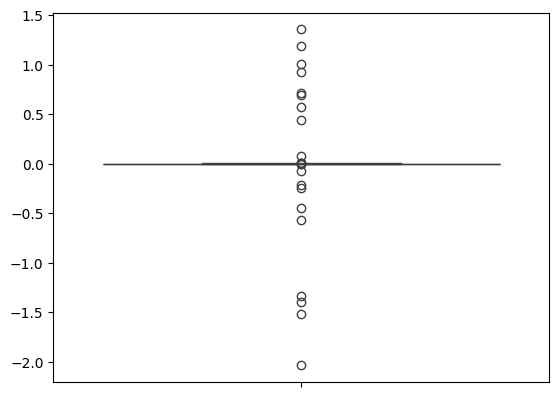

In [27]:
sns.boxplot(model2_weight_layer1)

In [28]:
model2_weight_layer1.max()

np.float32(1.3554823)

/tmp/ipykernel_58/2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
/tmp/ipykernel_58/2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

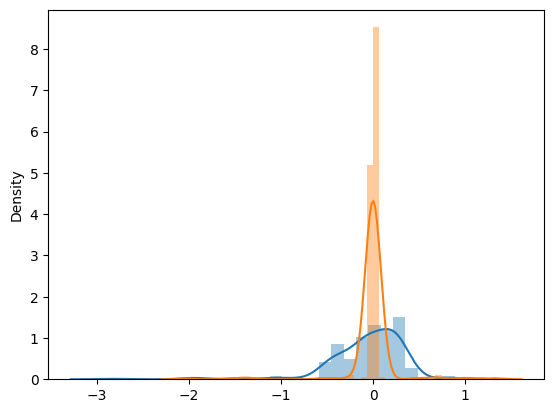

In [29]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)